## Requirements

In [1]:
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go           # для создания графиков
import plotly.express as px                  # для быстрых графиков
from plotly.subplots import make_subplots

from scipy.stats import skew, kurtosis


## DataFrame tryout 

In [2]:
data1 = [('truck', 1, 6),( 'car',34,7 ), ('lorry', 9,8), ('bicycle', 90,10)]
my_data_frame = pd.DataFrame(data1)
my_data_frame.columns = ['amount', 'object', 'cost']
print(my_data_frame)
print(my_data_frame['amount'])
my_data_frame.dtypes


    amount  object  cost
0    truck       1     6
1      car      34     7
2    lorry       9     8
3  bicycle      90    10
0      truck
1        car
2      lorry
3    bicycle
Name: amount, dtype: str


amount      str
object    int64
cost      int64
dtype: object

## House-prices dataframe

In [3]:
df = pd.read_csv('/Users/zakhar/ML/ml-course-homework/hw02_eda_full_c' \
'ycle/house-prices-advanced-regre' \
'ssion-techniques/train.csv')

## First inspection

In [4]:
display(df.head())
display(df.tail())
display(df.shape)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


(1460, 81)

## Info and Describe

In [5]:
display(df.info())
display(df.describe())
display(df.describe(include = 'object'))


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

None

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


/var/folders/sy/ywd1f6s508912_lp9n5s58dr0000gn/T/ipykernel_94958/4012612362.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include = 'object'))


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


## Data quality inspection

In [6]:
nan_to_process = pd.DataFrame(((df.isnull().sum() / len(df) * 100).round(2)[(df.isnull().sum() / len(df) * 100) > 0].sort_values(ascending=False)))
display(df.isnull().sum())
nan_to_process.columns = ['NaN_percent']
display(nan_to_process)
display(df.duplicated)
display(df.dtypes)

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

,NaN_percent
PoolQC,99.52
MiscFeature,96.30
Alley,93.77
Fence,80.75
MasVnrType,59.73
FireplaceQu,47.26
LotFrontage,17.74
GarageType,5.55
GarageYrBlt,5.55
GarageFinish,5.55


<bound method DataFrame.duplicated of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandCont

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

## NaN-cell process

## drop() 
delete all columns with >80% NaN-cells. This columns don't contain any information that can significantly effect data

In [7]:
cols_with_nulls = df.columns[df.isnull().any()].tolist()
print(f"Количество колонок с пропусками: {len(cols_with_nulls)}")
print(f"Список колонок: {cols_with_nulls}")

nan_to_delete = nan_to_process[nan_to_process['NaN_percent'] > 80].index.tolist()
df_before = df.copy()
display(df_before.shape)
df = df.drop(columns = nan_to_delete)
display(df.shape)

cols_with_nulls = df.columns[df.isnull().any()].tolist()
print(f"Количество колонок с пропусками: {len(cols_with_nulls)}")
print(f"Список колонок: {cols_with_nulls}")

Количество колонок с пропусками: 19
Список колонок: ['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


(1460, 81)

(1460, 77)

Количество колонок с пропусками: 15
Список колонок: ['LotFrontage', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']


## fillna()

median - resistant to access data

mean - little access data 

mode - categorical features

gmean - percentage  




## Numeric columns 

In [8]:
# get all numeric columns with NaN cells
numeric_columns = df.select_dtypes(include = [np.number])
numeric_columns_to_process = [col for col in numeric_columns if df[col].isnull().any()]
display(numeric_columns_to_process)

# we use median because the percentage of NaN-cells in LotFrontage column is relatively high
mediana = df['LotFrontage'].median()
df['LotFrontage'] = df['LotFrontage'].fillna(mediana)
display(mediana)

# fill all NaN-cells with 0 because MasVnrArea reflects area of coverage, 
# so if it is NaN we suppose the area is 0
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

# mean due to decent distribution of data 
meann = df['GarageYrBlt'].mean()
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(meann)
display(meann)

# display results
display(df['LotFrontage'].isnull().sum())
display(df['MasVnrArea'].isnull().sum())
display(df['GarageYrBlt'].isnull().sum())

cols_with_nulls = df.columns[df.isnull().any()].tolist()
print(f"Количество колонок с пропусками: {len(cols_with_nulls)}")
print(f"Список колонок: {cols_with_nulls}")
display(df[cols_with_nulls].dtypes)

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

np.float64(69.0)

np.float64(1978.5061638868744)

np.int64(0)

np.int64(0)

np.int64(0)

Количество колонок с пропусками: 12
Список колонок: ['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']


MasVnrType      str
BsmtQual        str
BsmtCond        str
BsmtExposure    str
BsmtFinType1    str
BsmtFinType2    str
Electrical      str
FireplaceQu     str
GarageType      str
GarageFinish    str
GarageQual      str
GarageCond      str
dtype: object

## Object columns 

In [9]:
# get all object columns with NaN-cells
object_columns = df.select_dtypes(include = [np.object_])
object_columns_to_process = [col for col in object_columns if df[col].isnull().any()]
#display(df[object_columns_to_process].isnull().sum()/len(df) * 100)
display(object_columns_to_process)
df['MasVnrType'] = df['MasVnrType'].fillna('None')
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# We know that there is a column 'Fireplaces' reflects amount of fireplaces in a house,
# so if it is 0, than fill 'FireplaceQu' with 'None', if it is >0 use mode
df.loc[df['Fireplaces'] == 0, 'FireplaceQu'] = df.loc[df['Fireplaces'] == 0, 'FireplaceQu'].fillna('None')
df['FireplaceQu'] = df['FireplaceQu'].fillna(df['FireplaceQu'].mode()[0])

# Do the same with other columns depending on wether it has numeric column or not 
no_basement = df['TotalBsmtSF'] == 0
for col in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
   df.loc[no_basement, col] = df.loc[no_basement, col].fillna('None')
   df[col] = df[col].fillna(df[col].mode()[0])

no_garage = df['GarageArea'] == 0
for col in ['GarageType', 'GarageFinish', 'GarageQual','GarageCond']:
   df.loc[no_garage, col] = df.loc[no_garage, col].fillna('None')
   df[col] = df[col].fillna(df[col].mode()[0]) 

#check results
object_columns_to_process = [col for col in object_columns if df[col].isnull().any()]
display(object_columns_to_process)





/var/folders/sy/ywd1f6s508912_lp9n5s58dr0000gn/T/ipykernel_94958/898749501.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include = [np.object_])


['MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond']

[]

In [10]:
display(df[df.isnull().any(axis=1)])
display(df.isnull().any().sum())

# now we see that we have got rid of all nan cells

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


np.int64(0)

## Extended statistics


general stats

In [11]:
list_info = []
info_columns = ['LotArea', 'YearBuilt', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'SalePrice']
for col in info_columns:
    stats = {
        'Признак': col,
        'min': df[col].min(),
        'max': df[col].max(),
        'mean': df[col].mean(),
        'median': df[col].median(),
        'mode': df[col].mode()[0],
        'std': df[col].std()
    }
    list_info.append(stats)
stats_df = pd.DataFrame(list_info)
display(stats_df)



,Признак,min,max,mean,median,mode,std
0,LotArea,1300,215245,10516.828082,9478.5,7200,9981.264932
1,YearBuilt,1872,2010,1971.267808,1973.0,2006,30.202904
2,1stFlrSF,334,4692,1162.626712,1087.0,864,386.587738
3,GrLivArea,334,5642,1515.463699,1464.0,864,525.480383
4,FullBath,0,3,1.565068,2.0,2,0.550916
5,TotRmsAbvGrd,2,14,6.517808,6.0,6,1.625393
6,SalePrice,34900,755000,180921.195890,163000.0,140000,79442.502883


Percentile

In [12]:

percentiles = [5, 25, 50, 75, 90, 95, 99]
for col in info_columns: 
    perc_values = np.percentile(df[col], percentiles)

    perc_df = pd.DataFrame({
    'Перцентиль': percentiles,
    'Значение': perc_values.round(2)
    })
    print(col)
    display(perc_df)


LotArea


,Перцентиль,Значение
0,5,3311.70
1,25,7553.50
2,50,9478.50
3,75,11601.50
4,90,14381.70
5,95,17401.15
6,99,37567.64


YearBuilt


,Перцентиль,Значение
0,5,1916.0
1,25,1954.0
2,50,1973.0
3,75,2000.0
4,90,2006.0
5,95,2007.0
6,99,2009.0


1stFlrSF


...

,Перцентиль,Значение
0,5,1.0
1,25,1.0
2,50,2.0
3,75,2.0
4,90,2.0
5,95,2.0
6,99,3.0


TotRmsAbvGrd


,Перцентиль,Значение
0,5,4.0
1,25,5.0
2,50,6.0
3,75,7.0
4,90,9.0
5,95,10.0
6,99,11.0


SalePrice


,Перцентиль,Значение
0,5,88000.00
1,25,129975.00
2,50,163000.00
3,75,214000.00
4,90,278000.00
5,95,326100.00
6,99,442567.01


extended

In [13]:
advanced_stats = []
for col in info_columns:
    variance = df[col].var()
    
    skewness = skew(df[col].dropna())
    
    kurt = kurtosis(df[col].dropna())

    advanced_stats.append({
        'Sign': col,
        'Variance': variance,
        'Skewness': skewness.round(3),
        'Kurt': kurt.round(3),
    })
info_df = pd.DataFrame(advanced_stats).round(3)
display(info_df)

,Sign,Variance,Skewness,Kurt
0,LotArea,9.962565e+07,12.195,202.544
1,YearBuilt,9.122150e+02,-0.613,-0.442
2,1stFlrSF,1.494501e+05,1.375,5.722
3,GrLivArea,2.761296e+05,1.365,4.874
4,FullBath,3.040000e-01,0.037,-0.858
5,TotRmsAbvGrd,2.642000e+00,0.676,0.874
6,SalePrice,6.311111e+09,1.881,6.510


## Encoding 

OneHot

In [14]:
cat_cols = df.select_dtypes(include=['object']).columns
low_cardinality = [col for col in cat_cols if df[col].nunique() < 10]

df_before_encoding = df.copy()

df_encoded = pd.get_dummies(df, columns=low_cardinality, drop_first=True)

print(df.shape)
print(df_encoded.shape)


(1460, 77)
(1460, 198)


/var/folders/sy/ywd1f6s508912_lp9n5s58dr0000gn/T/ipykernel_94958/1472636998.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Label Encoding

In [15]:
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

quality_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

df_label = df.copy()

for col in ordinal_cols:
    df_label[col + '_num'] = df_label[col].map(quality_map)

# Смотрим результат
df_label[ordinal_cols[:3] + [col + '_num' for col in ordinal_cols[:3]]].head()

,ExterQual,ExterCond,BsmtQual,ExterQual_num,ExterCond_num,BsmtQual_num
0,Gd,TA,Gd,4,3,4.0
1,TA,TA,Gd,3,3,4.0
2,Gd,TA,Gd,4,3,4.0
3,TA,TA,TA,3,3,3.0
4,Gd,TA,Gd,4,3,4.0


Feature Hashing

In [16]:
from sklearn.feature_extraction import FeatureHasher

neighborhood_list = df['Neighborhood'].astype(str).str.lower().str.replace(' ', '_').tolist()
neighborhood_features = [[x] for x in neighborhood_list]

hasher = FeatureHasher(n_features=10, input_type='string')
neighborhood_hashed = hasher.transform(neighborhood_features).toarray()

for i in range(10):
    df[f'Neighborhood_hash_{i}'] = neighborhood_hashed[:, i]

New features

In [17]:
df_fe = df.copy()

df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']

df_fe['Age_at_Sale'] = df_fe['YrSold'] - df_fe['YearBuilt']

df_fe['TotalBath'] = df_fe['FullBath'] + 0.5*df_fe['HalfBath'] + df_fe['BsmtFullBath'] + 0.5*df_fe['BsmtHalfBath']

df_fe['AreaPerRoom'] = df_fe['GrLivArea'] / (df_fe['TotRmsAbvGrd'] + 1)

df_fe[['TotalSF', 'Age_at_Sale', 'TotalBath', 'AreaPerRoom', 'SalePrice']].head()

,TotalSF,Age_at_Sale,TotalBath,AreaPerRoom,SalePrice
0,2566,5,3.5,190.000000,208500
1,2524,31,2.5,180.285714,181500
2,2706,7,3.5,255.142857,223500
3,2473,91,2.0,214.625000,140000
4,3343,8,3.5,219.800000,250000


## Visual 

Distributin

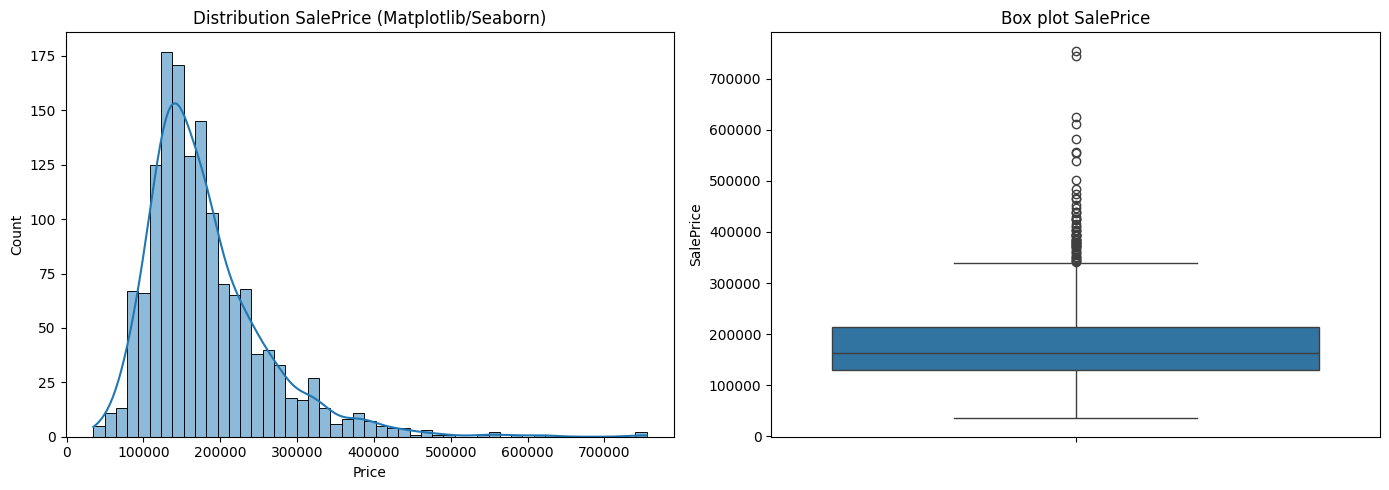

In [18]:
# Matplotlib + Seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Distribution SalePrice (Matplotlib/Seaborn)')
axes[0].set_xlabel('Price')

# Box plot
sns.boxplot(y=df['SalePrice'], ax=axes[1])
axes[1].set_title('Box plot SalePrice')

plt.tight_layout()
plt.show()

Dependences

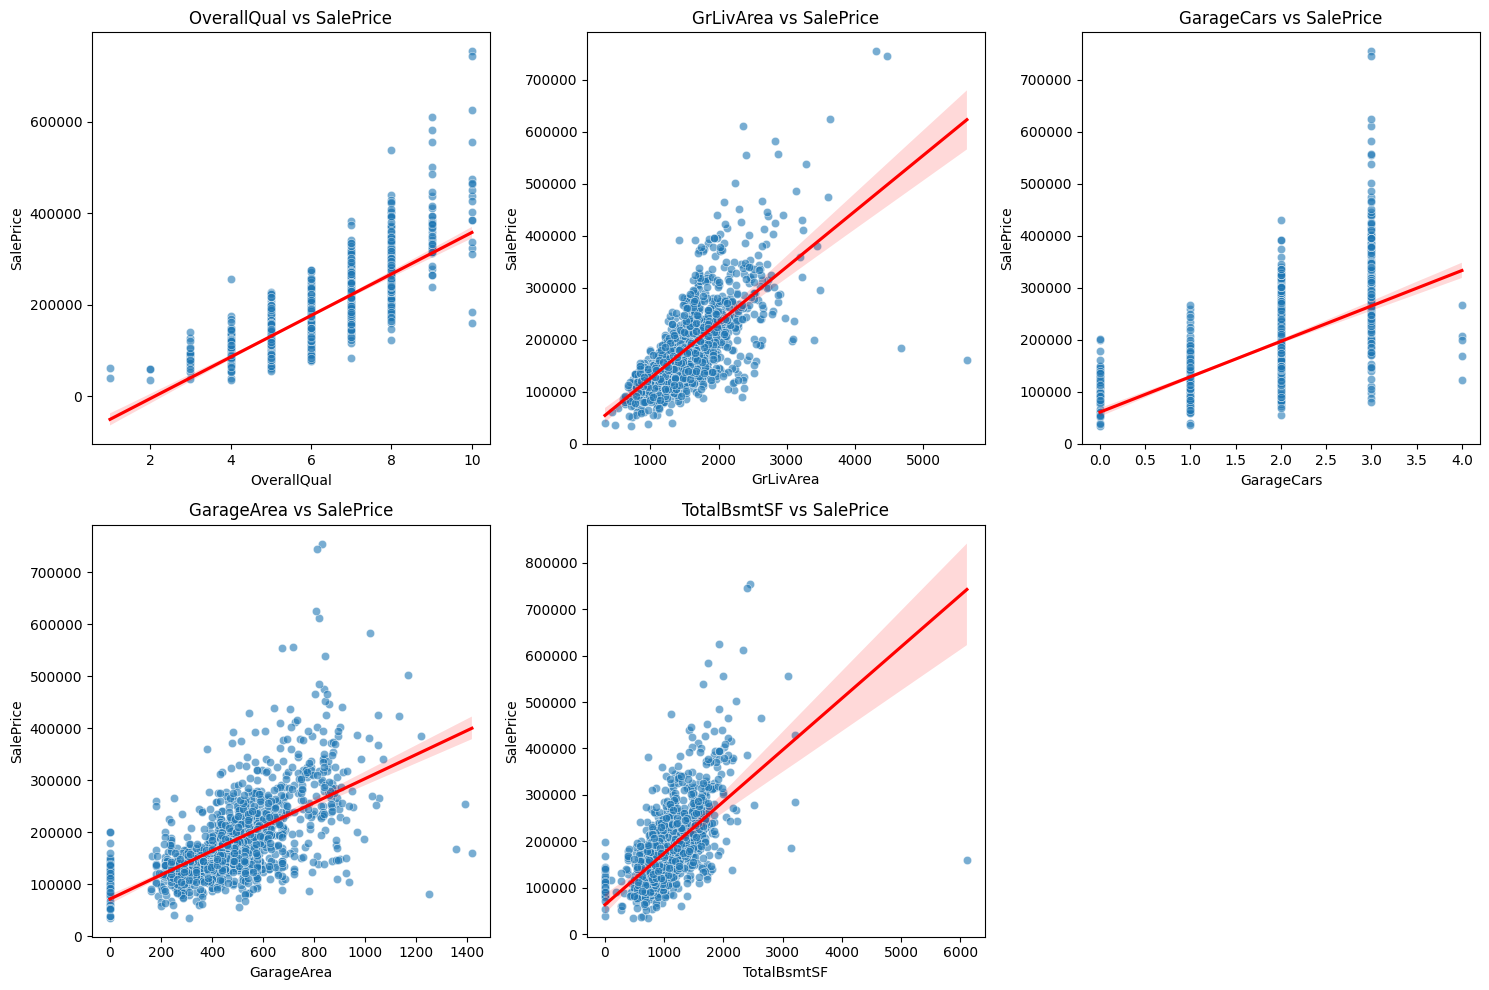

In [19]:
corr_with_price = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
top_features = corr_with_price.index[1:6]  

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.scatterplot(data=df, x=feature, y='SalePrice', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{feature} vs SalePrice')
    # regration
    sns.regplot(data=df, x=feature, y='SalePrice', ax=axes[i], 
                scatter=False, color='red')

if len(top_features) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.show()

Access data

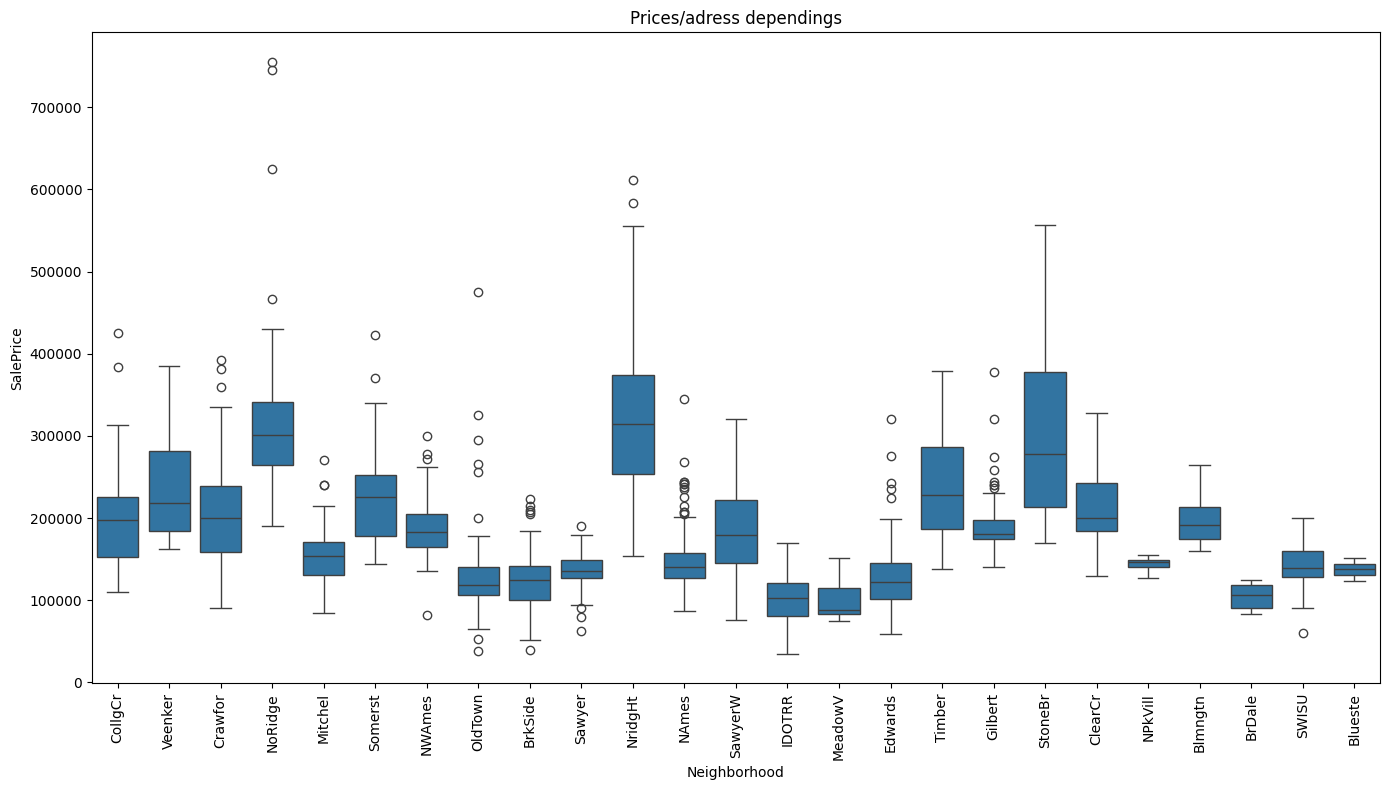

In [20]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice')
plt.xticks(rotation=90)
plt.title('Prices/adress dependings')
plt.tight_layout()
plt.show()

Count


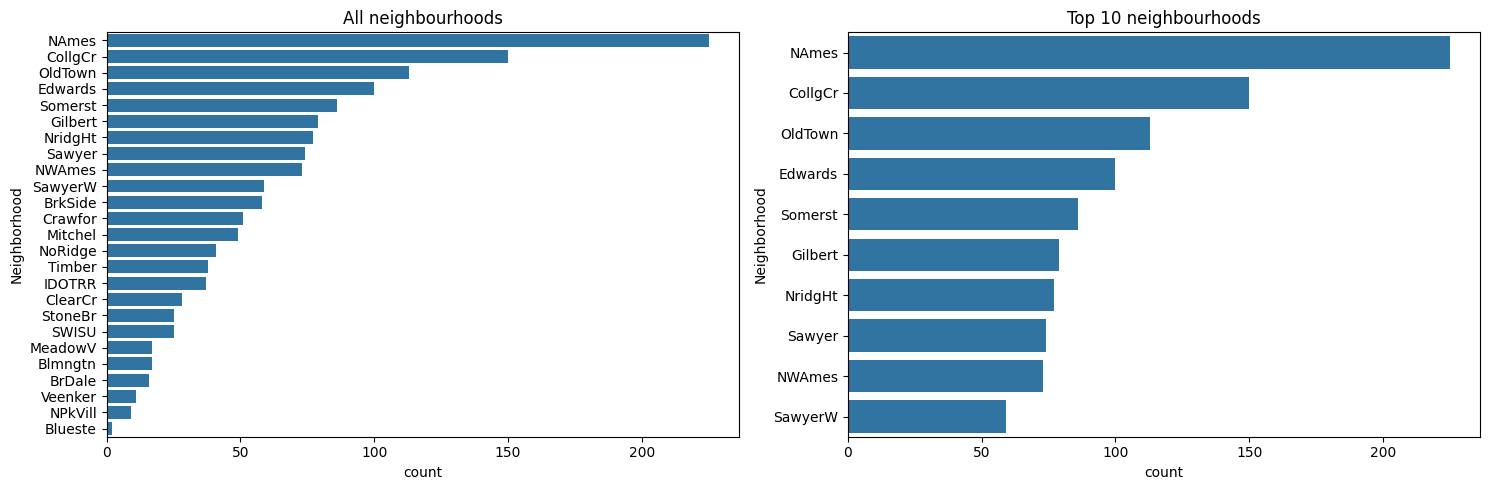

In [21]:
top_neighborhoods = df['Neighborhood'].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y='Neighborhood', order=df['Neighborhood'].value_counts().index, ax=axes[0])
axes[0].set_title('All neighbourhoods')

sns.countplot(data=df[df['Neighborhood'].isin(top_neighborhoods)], 
              y='Neighborhood', order=top_neighborhoods, ax=axes[1])
axes[1].set_title('Top 10 neighbourhoods')

plt.tight_layout()
plt.show()

Corr heatmap

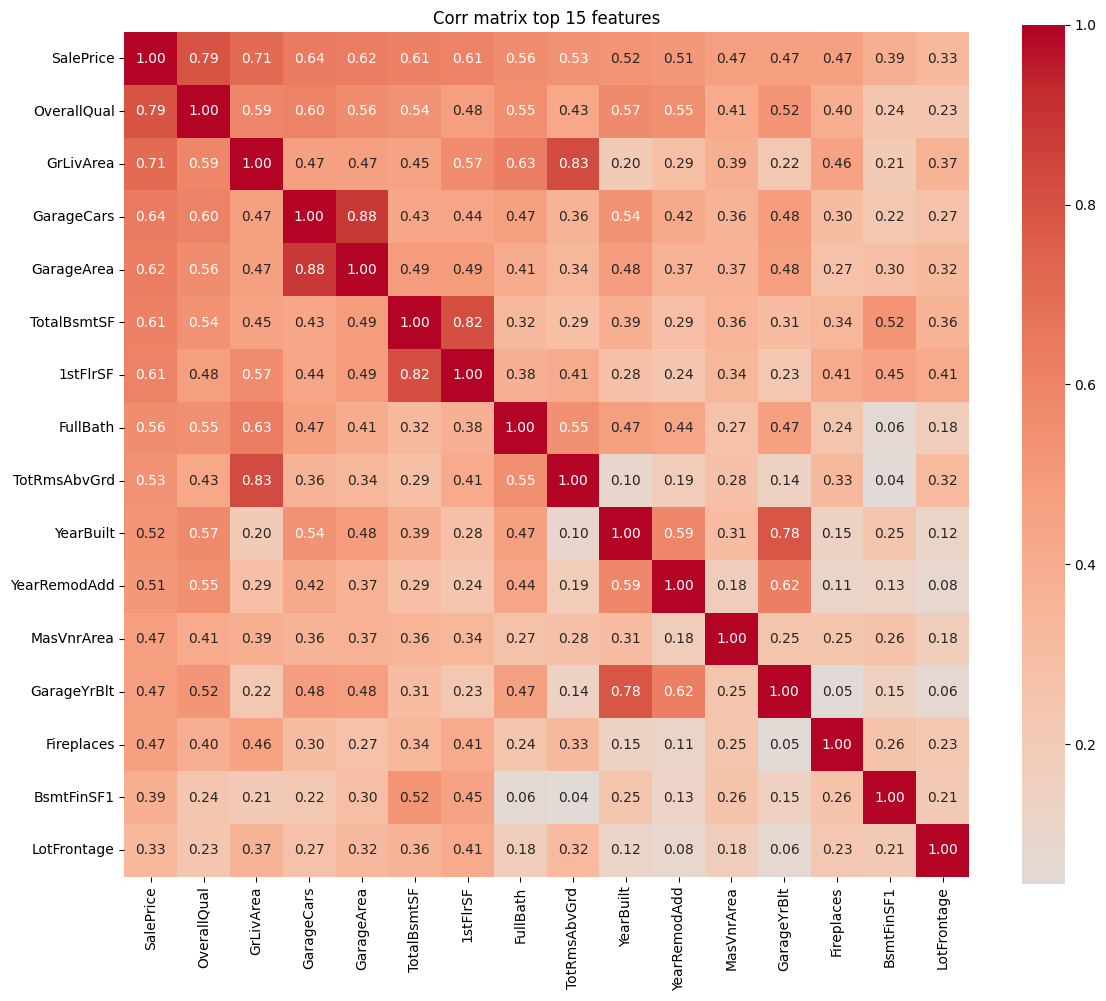

In [22]:
numeric_df = df.select_dtypes(include=[np.number])

correlation_matrix = numeric_df.corr()

price_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)

top_15 = price_corr.head(16).index  
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df[top_15].corr(), 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f')
plt.title('Corr matrix top 15 features')
plt.tight_layout()
plt.show()


## Выводы


1. **Целевая переменная (SalePrice)** правосторонняя ассиметрия 

2. **Топ-3 самых важных признака** для цены:
   - OverallQual 
   - GrLivArea 
   - GarageCars

3. **Пропуски**
   - Alley 
   - PoolQC 
   - FireplaceQu 

4. **Выбросы** — есть несколько домов с необычной ценой

5. **Районы** сильно влияют на цену

6. **Новые признаки** (общая площадь, возраст) хорозая corr  c ценой

7. **Мультиколлинеарность** очень много признаков у которых корреляция окло ~`0.9 

## Гипотезы и наблюдения

1. **Гипотеза:** Дома с подвалом стоят дороже, даже если подвал не отделан.

2. **Гипотеза:** Год постройки влияет наоборот, тоесть многие старые дома стоят дорого

##  Что делать дальше

1. **Модель:** Еще не могу сказать(

2. **Трансформации:** Для SalePrice нужно применить логарифмирование тк ассиметрия 

3. **Отбор признаков:** Удалить сильно коррелирующие 

4. **Обработка выбросов:** удалить те которые не заметил, например у которых аномальные характеристики

## Использование AI

**Что спрашивал у AI:**

-обьяснение всех команд тк не успел разобраться с библиотекой
-примеры признаков которые можно еще сгенерить
-отличия разных метрик 

**Что проверял/дописывал руками:**

-вцелом писал сам, но только после того как изучил все команды которые могут понадобиться на этапе 